# **Project Objective**

The goal of this project is to build a machine learning model that predicts whether a passenger survived the Titanic disaster based on demographic and travel-related features such as age, sex, passenger class, fare, and family size.

This project demonstrates the complete data science workflow, including data cleaning, exploratory data analysis, feature engineering, model training, and evaluation.

# **Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **Load Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv
Saving test.csv to test.csv


In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [ ]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Initial Data Exploration**

In [ ]:
train_df.shape

(891, 12)

In [ ]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Initial Observations

- The training dataset contains 891 rows and 12 columns.
- The target variable is `Survived`.
- Some columns contain missing values, especially `Age`, `Cabin`, and `Embarked`.
- Several columns are categorical, including `Sex` and `Embarked`.

# **Data Cleaning**

In [ ]:
df = train_df.copy()

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df = df.drop(columns=['Cabin', 'Ticket', 'Name'])

In [ ]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [ ]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


## Data Cleaning Decisions

- `Cabin` was removed because it contains too many missing values.
- `Ticket` was removed because it is less useful for this beginner-level model.
- `Name` was removed to keep the first project simple.
- Missing values in `Age` were filled with the median.
- Missing values in `Embarked` were filled with the mode.

# **Exploratory Data Analysis**

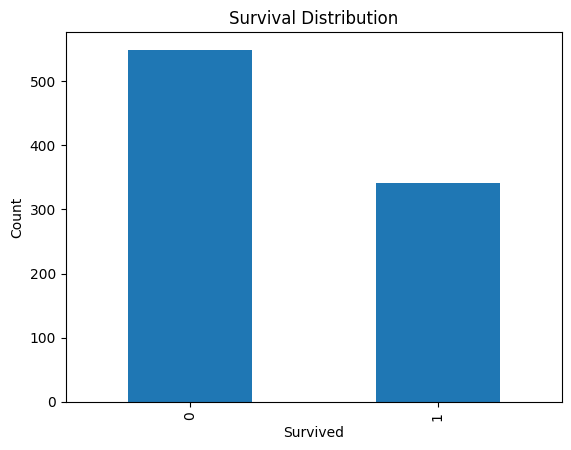

In [ ]:
df['Survived'].value_counts().plot(kind='bar')
plt.title('Survival Distribution')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.savefig('survival_distribution.png', bbox_inches='tight')
plt.show()

### Interpretation
The dataset shows that more passengers died than survived. This indicates that the target classes are somewhat imbalanced, although not severely.

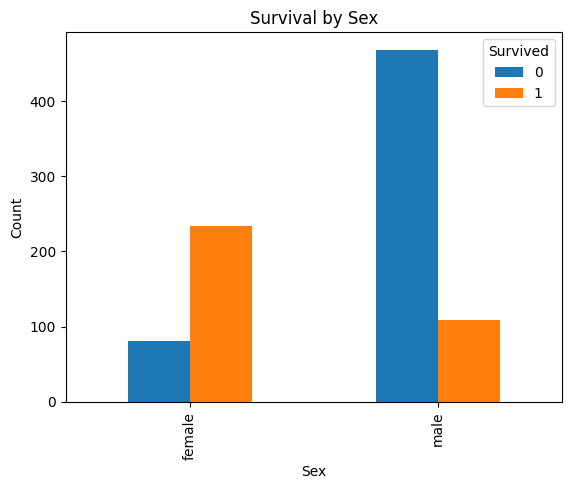

In [ ]:
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar')
plt.title('Survival by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.savefig('survival_sex.png', bbox_inches='tight')
plt.show()

### Interpretation
Female passengers had a much higher survival rate than male passengers. This suggests that sex is likely an important predictor.

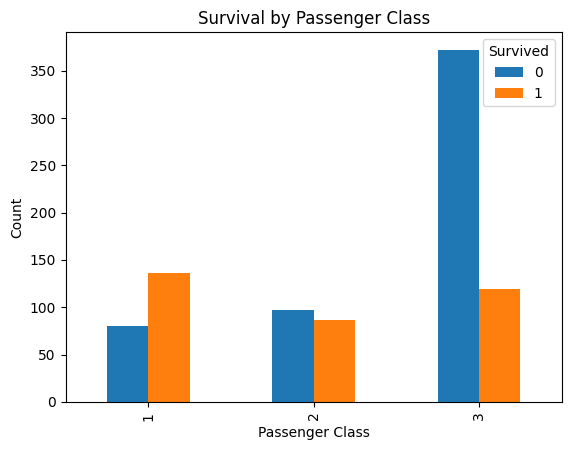

In [ ]:
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.savefig('survival_passengerClass.png', bbox_inches='tight')
plt.show()

### Interpretation
Passengers in first class had better survival outcomes than those in lower classes. Passenger class appears to be another relevant feature.

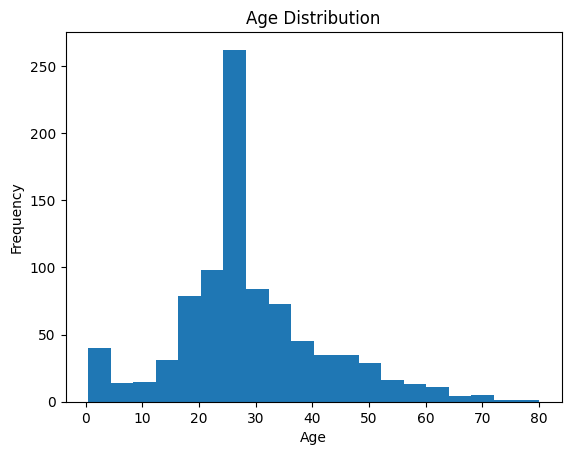

In [ ]:
df['Age'].plot(kind='hist', bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig('age_distribution.png', bbox_inches='tight')
plt.show()

### Interpretation
Most passengers were young adults, although the dataset includes children and older adults as well.

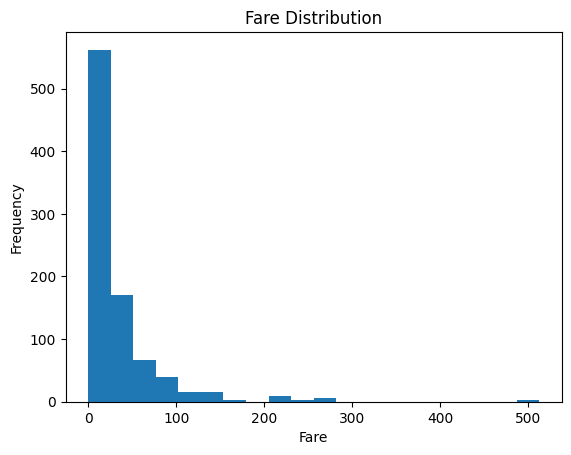

In [ ]:
df['Fare'].plot(kind='hist', bins=20)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.savefig('fare_distribution.png', bbox_inches='tight')
plt.show()

### Interpretation
The fare distribution is right-skewed, meaning that most passengers paid lower fares while a smaller group paid significantly higher amounts.

In [ ]:
files.download('survival_distribution.png')
files.download('survival_sex.png')
files.download('survival_passengerClass.png')
files.download('age_distribution.png')
files.download('fare_distribution.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Feature Engineering**

FamilySize

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

IsAlone

In [ ]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

Convert categorical variables to numeric variables

In [ ]:
df['Sex']= df['Sex'].map({'male':0, 'female':1})

In [ ]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,2,0,False,True
1,2,1,1,1,38.0,1,0,71.2833,2,0,False,False
2,3,1,3,1,26.0,0,0,7.9250,1,1,False,True
3,4,1,1,1,35.0,1,0,53.1000,2,0,False,True
4,5,0,3,0,35.0,0,0,8.0500,1,1,False,True


## Feature Engineering

Two additional features were created:

- `FamilySize`: total number of family members traveling together, including the passenger.
- `IsAlone`: indicates whether the passenger was traveling alone.

These features may capture family-related survival patterns.

# **Data Preparation for Modeling**

Delete PassengerId because it is not important for the model

In [ ]:
X = df.drop(columns=['Survived', 'PassengerId'])
y = df['Survived']

In [ ]:
X.shape, y.shape

((891, 10), (891,))

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train-Test Split

The dataset was split into training and validation sets using an 80/20 ratio in order to evaluate model performance on unseen data.

# **Model Training**

Logistic regression

In [ ]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_val)

Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_val)

# **Model Evaluation**

Accuracy

In [ ]:
lr_acc = accuracy_score(y_val, lr_preds)
dt_acc = accuracy_score(y_val, dt_preds)

print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)

Logistic Regression Accuracy: 0.8044692737430168
Decision Tree Accuracy: 0.7988826815642458


Classification Report

In [ ]:
print("Logistic Regression Report")
print(classification_report(y_val, lr_preds))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
print("Decision Tree Report")
print(classification_report(y_val, dt_preds))

Decision Tree Report
              precision    recall  f1-score   support

           0       0.84      0.81      0.83       105
           1       0.74      0.78      0.76        74

    accuracy                           0.80       179
   macro avg       0.79      0.80      0.79       179
weighted avg       0.80      0.80      0.80       179



Confusion Matrix

In [ ]:
print("Logistic Regression Confusion Matrix")
print(confusion_matrix(y_val, lr_preds))

Logistic Regression Confusion Matrix
[[90 15]
 [20 54]]


In [ ]:
print("Decision Tree Confusion Matrix")
print(confusion_matrix(y_val, dt_preds))

Decision Tree Confusion Matrix
[[85 20]
 [16 58]]


## Model Evaluation Summary

- Logistic Regression provides a strong and interpretable baseline for this binary classification task.
- Decision Tree may capture more complex patterns, but it can also overfit the data.
- The final comparison should be based not only on accuracy, but also on how the models classify survivors and non-survivors.

# **Conclusions**

## Conclusions

## Conclusions

This project implemented a complete data science workflow using the Titanic dataset, including data cleaning, exploratory data analysis, feature engineering, model training, and evaluation.

Two classification models were trained: Logistic Regression and Decision Tree. Both models achieved a similar overall accuracy of approximately 80% on the validation dataset, indicating that they are able to capture meaningful patterns in the data.

The Logistic Regression model showed slightly higher precision when predicting survivors, meaning that when it predicted that a passenger survived, it was correct about 78% of the time. However, its recall for survivors was lower, meaning it failed to identify some passengers who actually survived.

On the other hand, the Decision Tree model achieved higher recall for the survivor class. It correctly identified more actual survivors than the Logistic Regression model, although its precision was slightly lower.

Overall, both models performed comparably well for this problem. Logistic Regression provides a simpler and more interpretable baseline model, while the Decision Tree demonstrates the ability to capture more complex relationships in the data.

These results highlight how different models can perform similarly in terms of overall accuracy while exhibiting different strengths in terms of precision and recall.

# **Future Improvements**

Possible improvements for future versions of this project include:

- extracting titles from passenger names
- using cross-validation
- tuning hyperparameters
- trying more advanced models such as Random Forest
- improving feature engineering